In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification

**Setup and model load**

In [3]:
MODEL_DIR = "/content/drive/MyDrive/Fine tuned models/swin_beans_best"
OUTPUT_DIR = "/content/drive/MyDrive/Fine tuned models/swin_beans_best/images/multi_scale_inspection.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained(MODEL_DIR)

model = AutoModelForImageClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (attention): SwinAttention(
                (q_proj): Linear(in_features=96, out_features=96, bias=True)
                (k_proj): Linear(in_features=96, out_features=96, bias=True)
                (v_proj): Linear(in_features=96, out_features=96, bias=True)
                (o_proj): Linear(in_features=96, out_features=96, bias=True)
                (relative_position_bias): SwinRelativePositionBias()
              )
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
         

In [4]:
dataset = load_dataset("AI-Lab-Makerere/beans")

print("Device :", device)
print("Classes :", model.config.id2label)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  144MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.5MB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

Device : cuda
Classes : {0: 'angular_leaf_spot', 1: 'bean_rust', 2: 'healthy'}


#### Extract prediction and stage features

In [5]:
def extract_swin_features(image):
    inputs = processor(
        images=image.convert("RGB"),
        return_tensors="pt"
    )
    pixel_values = inputs["pixel_values"].to(device)
    
    with torch.inference_mode():
        backbone_outpus = model.swin(
            pixel_values=pixel_values,
            output_hidden_states=True,
            output_hidden_states_before_downsampling=True,
            return_dict=True
        )

        logits = model.classifier(backbone_outpus.pooler_output)
    
    probabilities = torch.softmax(logits, dim=-1)[0]
    
    stage_features = list(backbone_outpus.reshaped_hidden_states[-4:])
    return (
        pixel_values.cpu(),
        probabilities.cpu(),
        [
            feature.cpu() for feature in stage_features
        ],
    )

#### Create normalized activity map

In [ ]:
def create_activity_map(feature_map, output_size=(224, 224)):
    spatial_mean = feature_map.mean(
        dim=(2, 3), keepdim=True
    )
    activity = (feature_map - spatial_mean).pow(2).mean(dim=-1, keepdim=True).sqrt()
    
    activity = F.interpolate(
        activity,
        size=output_size,
        mode="bilinear",
        align_corners=False
    )[0, 0]
    
    minimum = activity.min()
    maximum = activity.max()
    
    activity = (activity - minimum) / (maximum - minimum + 1e-8)
    return activity

#### Recover the exact processed image

In [7]:
def recover_processed_image(pixel_values):
    image_tensor = pixel_values[0]
    mean = torch.tensor(processor.image_mean).view(3, 1, 1)
    
    standard_deviation = torch.tensor(processor.image_std).view(3, 1, 1)
    
    image_tensor = image_tensor * standard_deviation + mean
    image_tensor = image_tensor.clamp(0, 1)
    
    return (
        image_tensor
        .permute(1, 2, 0)
        .numpy()
    )

**Inspect one validation image**

In [9]:
SAMPLE_INDEX = 0
sample = dataset["validation"][SAMPLE_INDEX]

image = sample["image"].convert("RGB")
true_id = sample["labels"]
true_label = model.config.id2label[true_id]

pixel_values, probabilities, stage_features = extract_swin_features(image)

In [12]:
predicted_id = probabilities.argmax().item()
predicted_label = model.config.id2label[predicted_id]

confidence = probabilities[predicted_id].item()
top_scores, top_indices = torch.topk(
    probabilities, k=3
)

print("Ground truth:", true_label)
print("Prediction  :", predicted_label)
print(f"Confidence  : {confidence:.2%}")

Ground truth: angular_leaf_spot
Prediction  : angular_leaf_spot
Confidence  : 99.52%


In [13]:
for class_id, score in zip(
    top_indices.tolist(), top_scores.tolist()
):
      print(
        f"{model.config.id2label[class_id]:<22}"
        f"{score:.2%}"
    )


print("\nMulti-scale feature shapes:")
for stage_number, feature in enumerate(
    stage_features,
    start=1,
):
    print(
        f"Stage {stage_number}: "
        f"{tuple(feature.shape)}"
    )

angular_leaf_spot     99.52%
bean_rust             0.43%
healthy               0.05%

Multi-scale feature shapes:
Stage 1: (1, 96, 56, 56)
Stage 2: (1, 192, 28, 28)
Stage 3: (1, 384, 14, 14)
Stage 4: (1, 768, 7, 7)


**Generate four maps and fused map**

In [14]:
activity_maps = [
    create_activity_map(feature)
    for feature in stage_features
]

fused_activity_map = torch.stack(activity_maps).mean(dim=0)

processed_image = recover_processed_image(pixel_values)

print("Each activity map:", activity_maps[0].shape)
print("Fused activity map:", fused_activity_map.shape,)

Each activity map: torch.Size([224, 224])
Fused activity map: torch.Size([224, 224])


**Multi-scale Visualization**

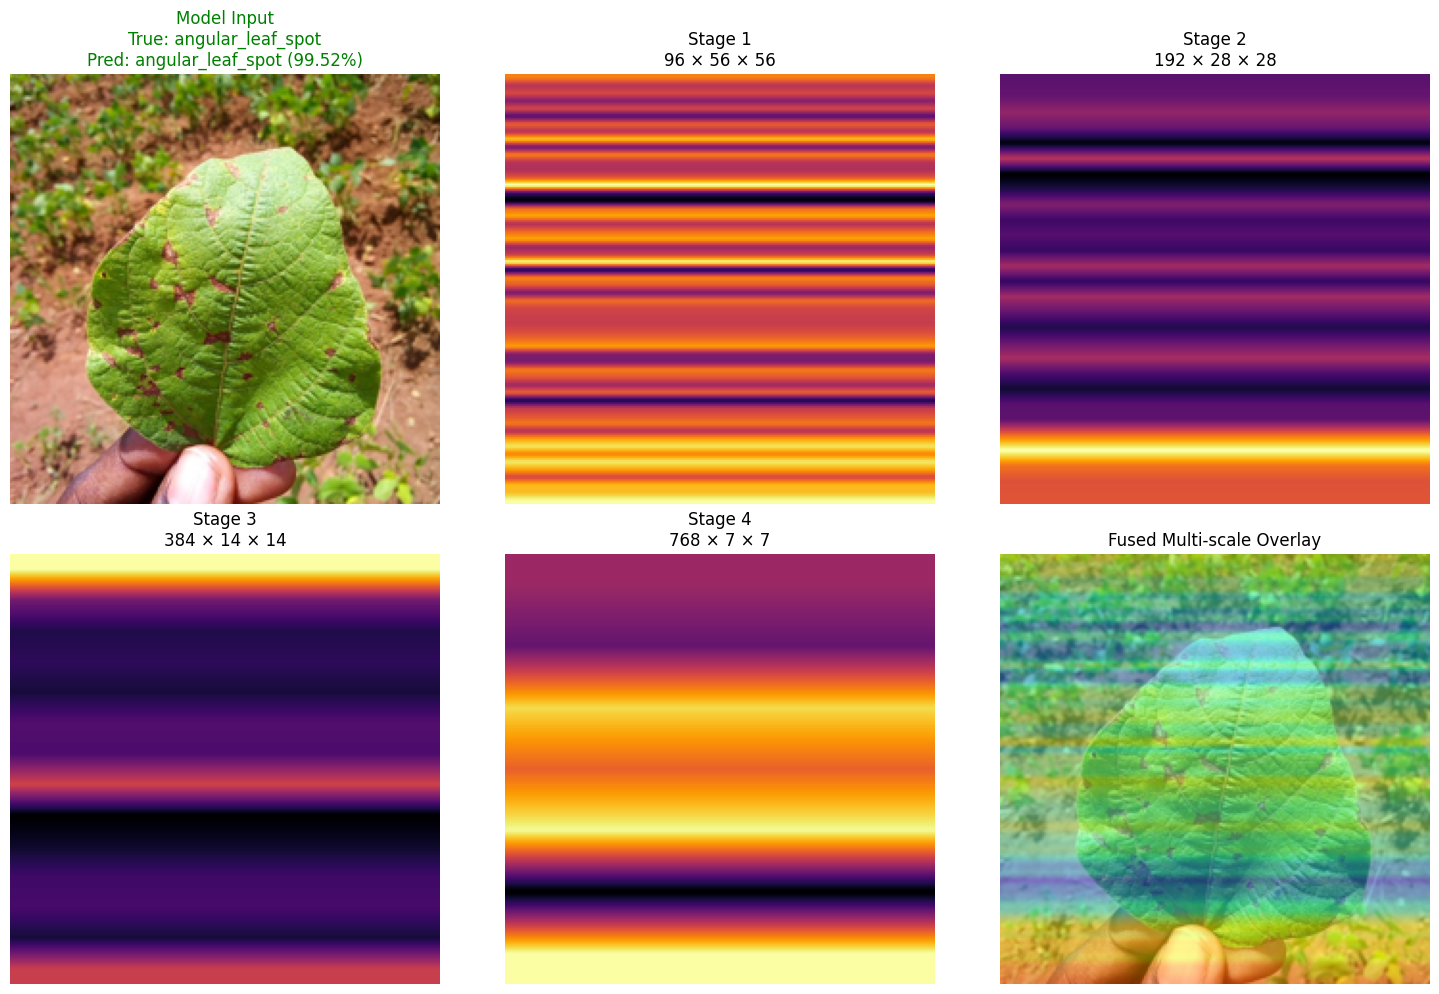

In [15]:
fix, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(processed_image)
axes[0].set_title(
    f"Model Input\n"
    f"True: {true_label}\n"
    f"Pred: {predicted_label} "
    f"({confidence:.2%})",
    color=(
        "green"
        if predicted_label == true_label
        else "red"
    ),
)

for stage_index in range(4):
    feature = stage_features[
        stage_index
    ]

    channels = feature.shape[1]
    height = feature.shape[2]
    width = feature.shape[3]

    axes[stage_index + 1].imshow(
        activity_maps[stage_index],
        cmap="inferno",
        vmin=0,
        vmax=1,
    )

    axes[stage_index + 1].set_title(
        f"Stage {stage_index + 1}\n"
        f"{channels} × "
        f"{height} × {width}"
    )

axes[5].imshow(processed_image)
axes[5].imshow(
    fused_activity_map,
    cmap="jet",
    alpha=0.45,
    vmin=0,
    vmax=1,
)
axes[5].set_title("Fused Multi-scale Overlay")


for axis in axes:
    axis.axis("off")

plt.tight_layout()
os.makedirs(
    os.path.dirname(OUTPUT_DIR),
    exist_ok=True,
)
plt.savefig(
    OUTPUT_DIR,
    dpi=170,
    bbox_inches="tight",
)
plt.show()